## Transmission

---

Transmission data describes the physical movement and availability of
electricity through the transmission system.

### Typical units

- Power flow: `MW`
- Unavailable capacity: `MW`

### Typical applications

- Transmission analysis
- Cross-border flow forecasting
- Grid outage analysis
- Congestion analysis
- Electricity price forecasting

# Config

---

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("ggplot")

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Settings

---

In [3]:
# Location
country_capital = "Madrid"
country_code = "ES"

# Period
tz = f"Europe/{country_capital}"

now = pd.Timestamp.now(tz=tz)
today = now.normalize()

yesterday = today - pd.Timedelta(days=1)
last_week = today - pd.Timedelta(days=7)
last_month = today - pd.DateOffset(months=1)

tomorrow = today + pd.Timedelta(days=1)
day_after_tomorrow = today + pd.Timedelta(days=2)
next_week = today + pd.Timedelta(days=7)
next_month = today + pd.DateOffset(months=1)

# EDA
---

###################################################################################
# .query_physical_crossborder_allborders
(country_code, start, end, export=True) -> pd.DataFrame

In [15]:
physical_crossborder_allborders = entsoe_client.query_physical_crossborder_allborders(
    country_code=country_code,
    start=last_week, 
    end=today, 
    export=True)

In [16]:
physical_crossborder_allborders.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-08-27 00:00:00+02:00 to 2026-09-02 23:45:00+02:00
Freq: 15min
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FR      672 non-null    float64
 1   PT      672 non-null    float64
 2   sum     672 non-null    float64
dtypes: float64(3)
memory usage: 21.0 KB


In [17]:
physical_crossborder_allborders.head()

,FR,PT,sum
2026-08-27 00:00:00+02:00,0.0,1997.56,1997.56
2026-08-27 00:15:00+02:00,0.0,1153.88,1153.88
2026-08-27 00:30:00+02:00,0.0,839.96,839.96
2026-08-27 00:45:00+02:00,0.0,942.72,942.72
2026-08-27 01:00:00+02:00,0.0,689.60,689.60


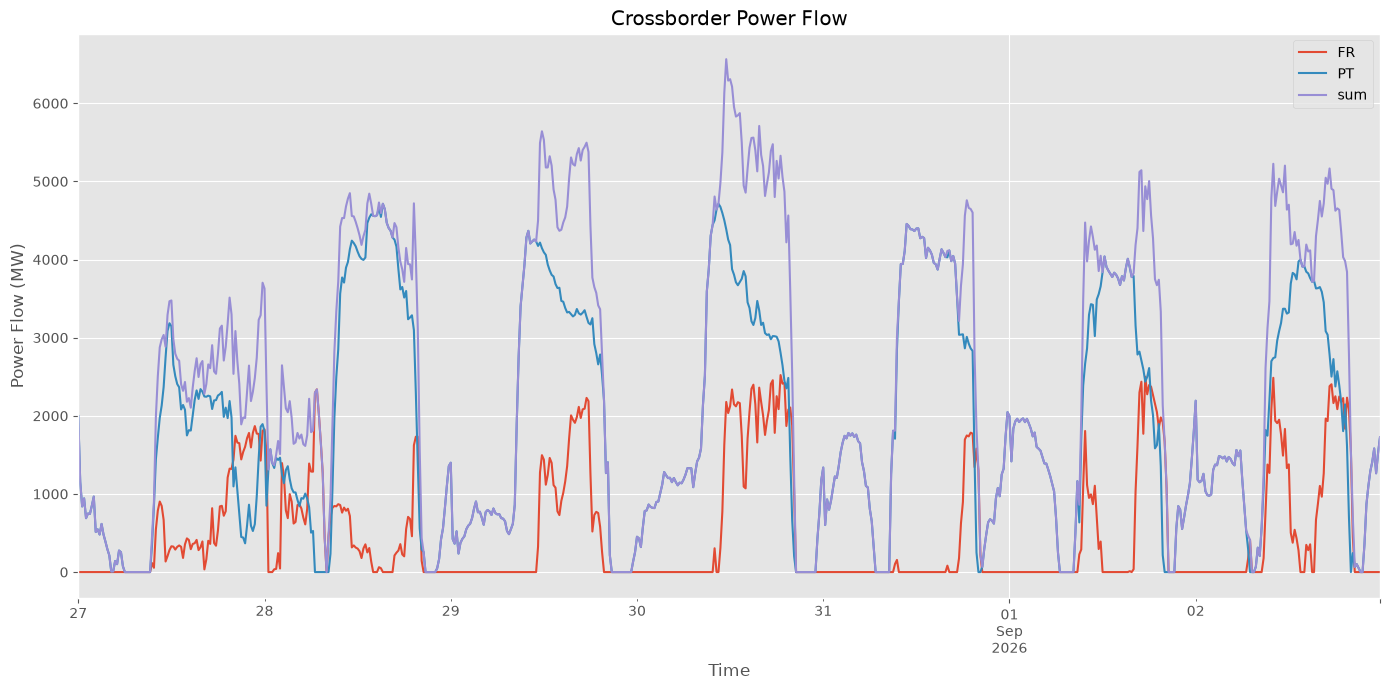

In [18]:
fig, ax = plt.subplots(figsize=(14, 7))

physical_crossborder_allborders.plot(ax=ax)

ax.set_title("Crossborder Power Flow")
ax.set_xlabel("Time")
ax.set_ylabel("Power Flow (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_crossborder_flows
(country_code_from, country_code_to, start=start, end=end) -> pd.Series

<p>How much electricity physically flowed across the border?</p>

In [4]:
crossborder_flows = entsoe_client.query_crossborder_flows(
    country_code_from="ES",
    country_code_to="FR",
    start=last_week,
    end=today)

In [5]:
crossborder_flows.info()

<class 'pandas.Series'>
DatetimeIndex: 672 entries, 2026-08-27 00:00:00+02:00 to 2026-09-02 23:45:00+02:00
Freq: 15min
Series name: None
Non-Null Count  Dtype  
--------------  -----  
672 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB


In [6]:
crossborder_flows.head()

2026-08-27 00:00:00+02:00    0.0
2026-08-27 00:15:00+02:00    0.0
2026-08-27 00:30:00+02:00    0.0
2026-08-27 00:45:00+02:00    0.0
2026-08-27 01:00:00+02:00    0.0
Freq: 15min, dtype: float64

In [7]:
crossborder_flows.tail()

2026-09-02 22:45:00+02:00    0.0
2026-09-02 23:00:00+02:00    0.0
2026-09-02 23:15:00+02:00    0.0
2026-09-02 23:30:00+02:00    0.0
2026-09-02 23:45:00+02:00    0.0
Freq: 15min, dtype: float64

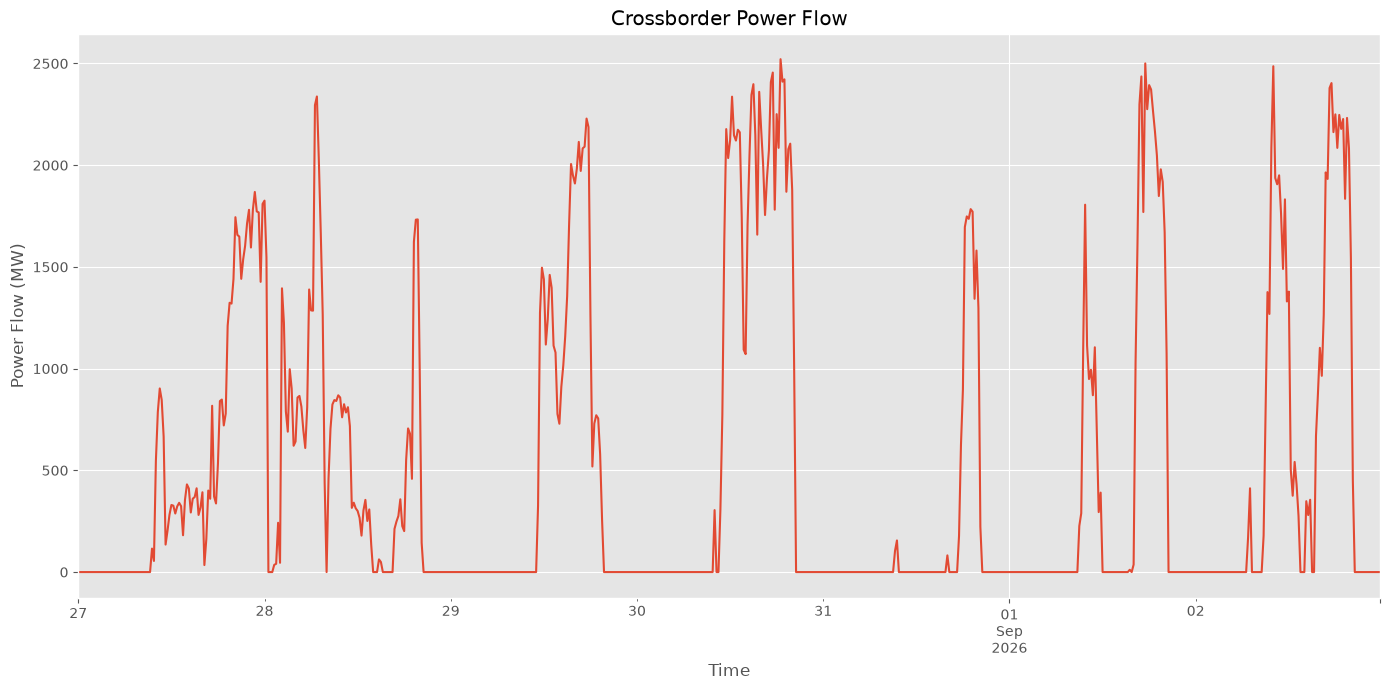

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

crossborder_flows.plot(ax=ax)

ax.set_title("Crossborder Power Flow")
ax.set_xlabel("Time")
ax.set_ylabel("Power Flow (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_net_transfer_capacity_dayhead()
# .query_net_transfer_capacity_weekhead()
# .query_net_transfer_capacity_monthahead()
# .query_net_transfer_capacity_yearahead()

(country_code_from, country_code_to, start=start, end=end) -> pd.Series

<p>How much transfer capacity is available?</p>

In [ ]:
net_transfer_capacity_dayhead = entsoe_client.query_net_transfer_capacity_dayahead(
    country_code_from="ES",
    country_code_to="FR",
    start=last_week,
    end=today)

In [ ]:
net_transfer_capacity_dayhead.info()

<class 'pandas.Series'>
DatetimeIndex: 168 entries, 2026-08-21 00:00:00+02:00 to 2026-08-27 23:00:00+02:00
Freq: 60min
Series name: None
Non-Null Count  Dtype  
--------------  -----  
168 non-null    float64
dtypes: float64(1)
memory usage: 2.6 KB


In [ ]:
net_transfer_capacity_dayhead.head()

2026-08-21 00:00:00+02:00    3376.0
2026-08-21 01:00:00+02:00    3376.0
2026-08-21 02:00:00+02:00    3376.0
2026-08-21 03:00:00+02:00    3376.0
2026-08-21 04:00:00+02:00    3376.0
Freq: 60min, dtype: float64

In [ ]:
net_transfer_capacity_dayhead.tail()

2026-08-27 19:00:00+02:00    1300.0
2026-08-27 20:00:00+02:00    2300.0
2026-08-27 21:00:00+02:00    2300.0
2026-08-27 22:00:00+02:00    2300.0
2026-08-27 23:00:00+02:00    2300.0
Freq: 60min, dtype: float64

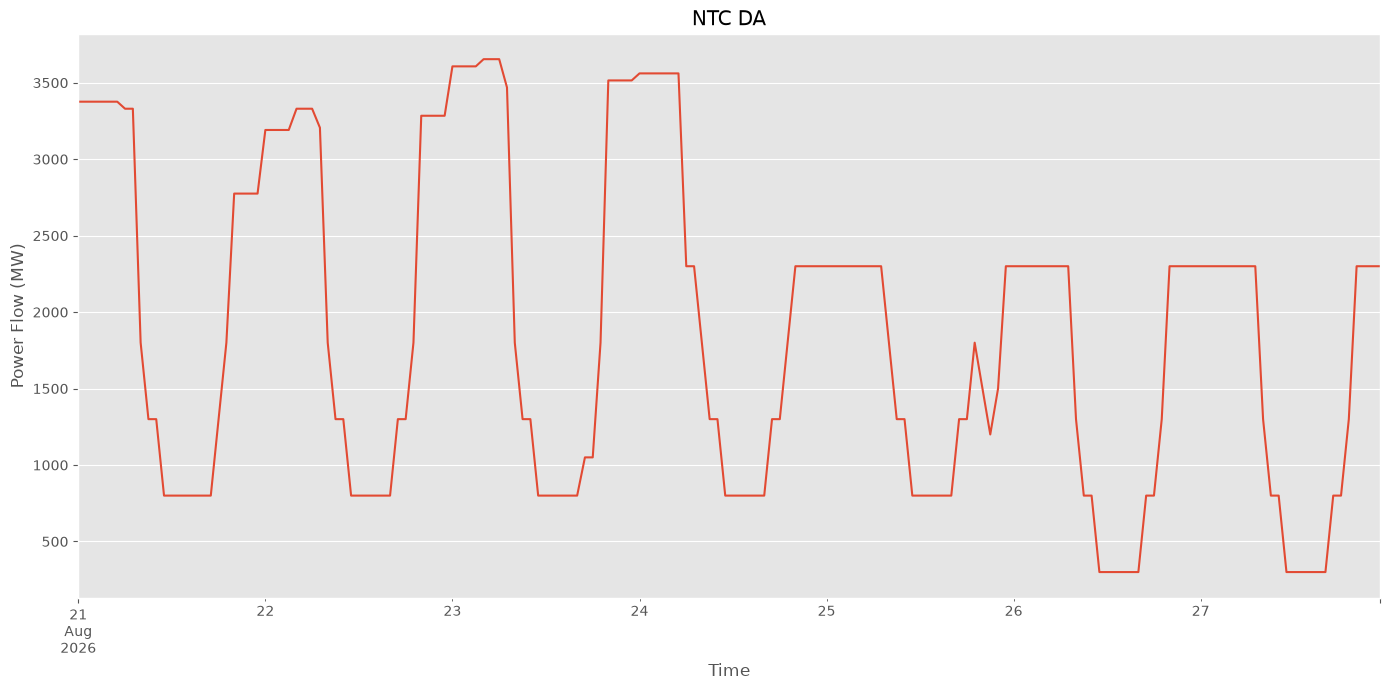

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

net_transfer_capacity_dayhead.plot(ax=ax)

ax.set_title("NTC DA")
ax.set_xlabel("Time")
ax.set_ylabel("Power Flow (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_import
(country_code, start, end) -> pd.DataFrames

In [ ]:
import_ = entsoe_client.query_import(
    country_code=country_code,
    start=last_week, 
    end=today, 
)

In [ ]:
import_.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-08-21 00:00:00+02:00 to 2026-08-27 23:45:00+02:00
Freq: 15min
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FR      672 non-null    float64
 1   PT      672 non-null    float64
 2   sum     672 non-null    float64
dtypes: float64(3)
memory usage: 21.0 KB


In [ ]:
import_.head()

,FR,PT,sum
2026-08-21 00:00:00+02:00,0.00,0.0,0.00
2026-08-21 00:15:00+02:00,1622.64,0.0,1622.64
2026-08-21 00:30:00+02:00,1826.40,0.0,1826.40
2026-08-21 00:45:00+02:00,1921.68,0.0,1921.68
2026-08-21 01:00:00+02:00,1896.72,0.0,1896.72


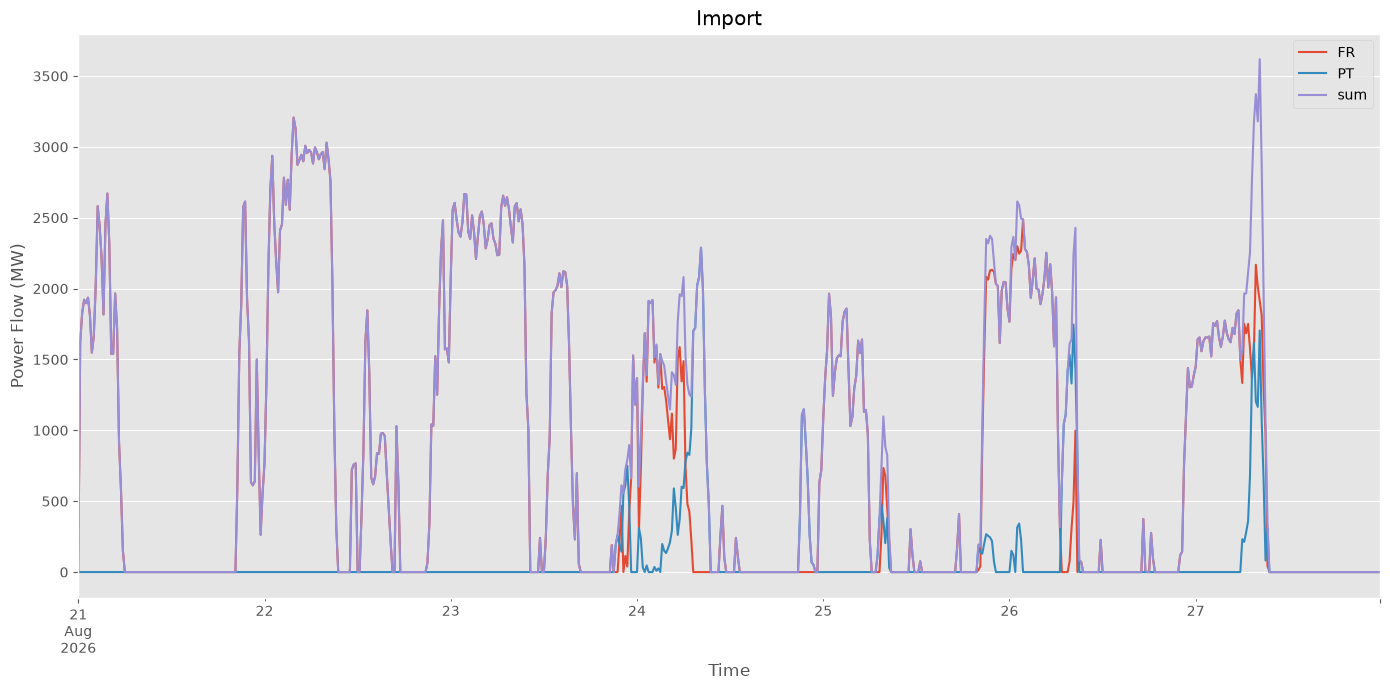

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

import_.drop(columns=["sum"])
import_.plot(ax=ax)

ax.set_title("Import")
ax.set_xlabel("Time")
ax.set_ylabel("Power Flow (MW)")

fig.tight_layout()
plt.show()